In [14]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    #total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    #use geqdsk pressure for now
    total_pressure = gfile['PRES']
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

[12.91034087 12.32765566 11.64852226 15.46638051 13.65466796 10.99126003]


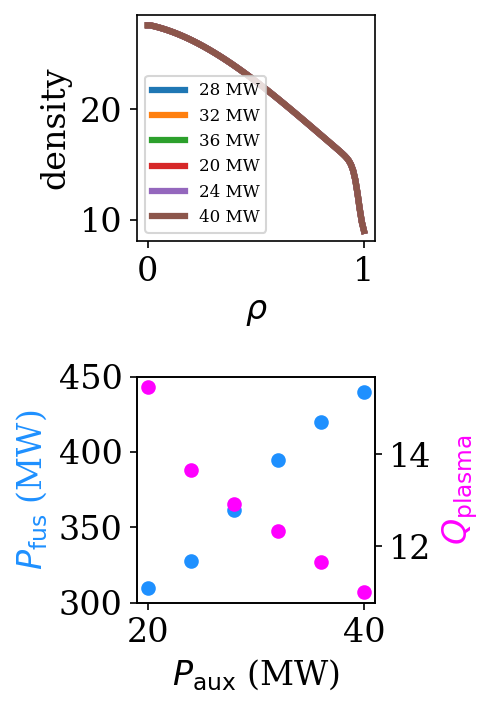

In [52]:
from netCDF4 import Dataset
from sys import argv
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    
    fig = plt.figure('fig_offset', figsize=(3.58,5),dpi = 150)
    gs = mpl.gridspec.GridSpec(2,1, figure=fig, height_ratios=[1,1])
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    axs[2] = fig.add_subplot(gs[1,0])
    #axs[3] = fig.add_subplot(gs[1,0])
    #axs[4] = fig.add_subplot(gs[1,1])
    
    ax1 = axs[1]
    #ax1cb = axs[2]
    ax2 = axs[2]

    # First just find the fastran.nc file ================
    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]

    prf_array = []
    pfus_array = []
    for sim in sims:
        work_dir = SCAN_dir+'/'+sim+'/work'
        fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
        ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
    #=====================================================
    
        rootgrp = Dataset(ffile)
    
        rho = rootgrp['rho'][:]
    
        ne = rootgrp['ne'][-1,:]
        nebar = rootgrp['nebar'][-1]
        ni = rootgrp['ni'][-1,:]
    
        te = rootgrp['te'][-1,:]
        teavg = rootgrp['tea'][-1]
        ti = rootgrp['ti'][-1,:]
        tiavg = rootgrp['tia'][-1]
    
        ipol = rootgrp['ipol'][-1,:]
        ip = rootgrp['ip'][-1]
    
        prfe = rootgrp['pe_rf'][-1,:]
        prfe_int = rootgrp['prfe'][-1]
        prfi = rootgrp['pi_rf'][-1,:]
        prfi_int = rootgrp['prfi'][-1]
    
        pfuse = rootgrp['pe_fus'][-1,:]
        pfuse_int = rootgrp['pfuse'][-1]
        pfusi = rootgrp['pi_fus'][-1,:]
        pfusi_int = rootgrp['pfusi'][-1]
    
        q = rootgrp['q'][-1,:]
    
        jbs = rootgrp['j_bs'][-1,:]
        ibs = rootgrp['ibs'][-1]
        jrf = rootgrp['j_rf'][-1,:]
        irf = rootgrp['irf'][-1]
        jtot = rootgrp['j_tot'][-1,:]
    
        fluxe = rootgrp['fluxe'][-1,:]
        fluxe_exp = rootgrp['fluxe_exp'][-1,:]
        fluxi = rootgrp['fluxi'][-1,:]
        fluxi_exp = rootgrp['fluxi_exp'][-1,:]

        prf_array.append(prfe_int+prfi_int)
        pfus_array.append(5*(pfuse_int+pfusi_int))
    
        var_dic = {'ne':ne,'ni':ni,'te':te,'ti':ti,'ipol':ipol,'jbs':jbs,'jrf':jrf,'jtot':jtot,'pfus':5*(pfuse+pfusi),'paux':prfe+prfi,'q':q}
        lw = 2
        c1 = 'green'
        c2 = 'lime'
        c3 = 'magenta'
        c4 = 'darkviolet'
        c5 = 'dodgerblue'
        c6 = 'cyan'
        
        ax1.plot(rho,var_dic['ne'],label = '{:.0f} MW'.format(prfe_int + prfi_int))

    Q = np.array(pfus_array)/np.array(prf_array)
    print(Q)
    ax2.scatter(prf_array,pfus_array,color = 'dodgerblue')
    ax2.yaxis.label.set_color('dodgerblue')
    ax2.set_xlabel('$P_\\mathrm{aux}$ (MW)')
    ax2.set_ylabel('$P_\\mathrm{fus}$ (MW)')
    ax2.set_ylim(300,450)
    ax1.set_xlabel('$\\rho$')
    ax1.set_ylabel('density')
    ax3 = ax2.twinx()
    ax3.scatter(prf_array,Q,color = 'magenta')
    ax3.set_ylabel('$Q_\\mathrm{plasma}$')
    ax3.yaxis.label.set_color('magenta')

    fig.tight_layout()
    ax1.legend(fontsize = 8)
    plt.show()
    


In [20]:
print(prf_array)

[28.016326806749717, 32.017198675711796, 36.01748442736801, 20.012738287632768, 24.01510163893855, 40.01806607392149]
